<a href="https://colab.research.google.com/github/anshikaaloksingh06-hue/Face-Recognition-Attendance/blob/main/FaceRecognitionAttendance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=913f7d3a96b49a37bf45042d79811902f282190498155f9e298639a5a6c1c9f7
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [6]:
from google.colab import files
import os
os.makedirs('my_faces', exist_ok=True)
uploaded = files.upload()
for fn in uploaded.keys():
  os.rename(fn, f'my_faces/{fn}')

Saving WhatsApp Image 2026-03-24 at 16.33.42 (1).jpeg to WhatsApp Image 2026-03-24 at 16.33.42 (1).jpeg
Saving WhatsApp Image 2026-03-24 at 16.33.42 (2).jpeg to WhatsApp Image 2026-03-24 at 16.33.42 (2).jpeg
Saving WhatsApp Image 2026-03-24 at 16.33.42.jpeg to WhatsApp Image 2026-03-24 at 16.33.42.jpeg
Saving WhatsApp Image 2026-03-24 at 16.33.43.jpeg to WhatsApp Image 2026-03-24 at 16.33.43.jpeg
Saving WIN_20260324_16_37_51_Pro.jpg to WIN_20260324_16_37_51_Pro.jpg


In [7]:
import face_recognition
import numpy as np
import pandas as pd
from datetime import datetime
from PIL import Image
import matplotlib.pyplot as plt

known_encodings = []
known_names = ['Anshika']

for file in os.listdir('my_faces'):
    try:
        image = face_recognition.load_image_file(f'my_faces/{file}')
        encodings = face_recognition.face_encodings(image)
        if len(encodings) > 0:  # Face found!
            encoding = encodings[0]
            known_encodings.append(encoding)
            print(f"✅ Used {file}")
        else:
            print(f"❌ No face in {file}")
    except Exception as e:
        print(f"❌ Error {file}: {e}")

known_encodings = np.array(known_encodings)
print(f"✅ {len(known_encodings)} photos trained for Anshika!")

✅ Used WhatsApp Image 2026-03-24 at 16.33.42 (1).jpeg
✅ Used WIN_20260324_16_37_51_Pro.jpg
❌ No face in WhatsApp Image 2026-03-24 at 16.33.42 (2).jpeg
✅ Used WhatsApp Image 2026-03-24 at 16.33.43.jpeg
✅ Used WhatsApp Image 2026-03-24 at 16.33.42.jpeg
✅ 4 photos trained for Anshika!


In [16]:
from google.colab import files
test_file = list(files.upload().keys())[0]

import face_recognition
from datetime import datetime
import pytz

# IST timezone
ist = pytz.timezone('Asia/Kolkata')
now_ist = datetime.now(ist)

test_image = face_recognition.load_image_file(test_file)
test_encodings = face_recognition.face_encodings(test_image)

if len(test_encodings) > 0:
    test_encoding = test_encodings[0]
    matches = face_recognition.compare_faces(known_encodings, test_encoding, tolerance=0.6)
    name = known_names[0] if any(matches) else "Unknown"

    df = pd.DataFrame({'Student': [name], 'Time': [now_ist]})
    df.to_csv('attendance.csv', index=False)

    print(f"✅ Recognized: {name} at {now_ist}")
    print(df)
else:
    print("❌ No face in test photo")

Saving WIN_20260324_16_41_56_Pro.jpg to WIN_20260324_16_41_56_Pro (1).jpg
✅ Recognized: Anshika at 2026-03-24 16:46:16.505802+05:30
   Student                             Time
0  Anshika 2026-03-24 16:46:16.505802+05:30


In [18]:
from google.colab import files
files.download('attendance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

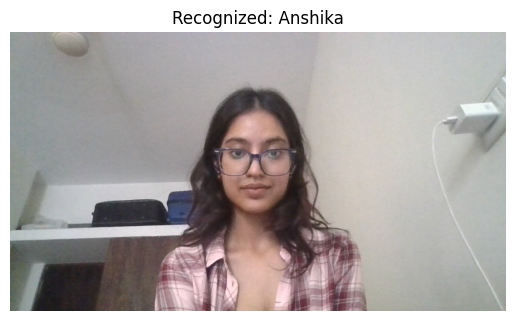

In [17]:
import matplotlib.pyplot as plt
plt.imshow(test_image)
plt.title(f"Recognized: {name}")
plt.axis('off')
plt.show()